# Actividad 3: Support Vector Machines vs. Multilayer Perceptron
## Héctor Arturo Hernández Escalante
### Profesor: Dr. Victor Uc
### Maestría en Ciencias de la Computación
### Segundo Semestre
### Universidad Autónoma de Yucatán
### 27 de Marzo 2026

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

In [3]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train = StandardScaler().fit_transform(x_train)
X_test = StandardScaler().fit_transform(x_test)

In [4]:
linear = SVC(kernel = 'linear')
poly3 = SVC(kernel = 'poly', degree = 3)
rbf = SVC(kernel = 'rbf')
sigmoid = SVC(kernel = 'sigmoid')
models = [linear, poly3, rbf, sigmoid]

In [5]:
results = []
names = ['Linear', 'Poly3', 'RBF', 'Sigmoid']
for i, model in enumerate(models):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': f'SVM - {names[i]}', 'Accuracy': acc, 'Precision': prec, 'Recall': recall, 'F1': f1})

In [6]:
clf1 = MLPClassifier(hidden_layer_sizes = (64,), max_iter = 1000, random_state = 42)
clf2 = MLPClassifier(hidden_layer_sizes = (64, 64), max_iter = 1000, random_state = 42)
clf3 = MLPClassifier(hidden_layer_sizes = (64, 64, 64), max_iter = 1000, random_state = 42)
clf4 = MLPClassifier(hidden_layer_sizes = (64, 64, 64, 64), max_iter = 1000, random_state = 42)
models = [clf1, clf2, clf3, clf4]

In [7]:
names = ['1_hidden', '2_hidden', '3_hidden', '4_hidden']
for i, model in enumerate(models):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': f'MLP - {names[i]}', 'Accuracy': acc, 'Precision': prec, 'Recall': recall, 'F1': f1})

| **Model** | **Accuracy** | **Precision** | **Recall** | **F1-score** |
|---|---|---|---|---|
| SVM - Linear | 0.97 | 0.96 | 1.0 | 0.98 |
| SVM - Polynomial | 0.87 | 0.83 | 1.0 | 0.9 |
| SVM - RBF | 0.98 | 0.97 | 1.0 | 0.99 |
| SVM - Sigmoid | 0.95 | 0.93 | 0.99 | 0.96 |
| MLP - 1 layer | 0.98 | 0.97 | 1.0 | 0.99 |
| MLP - 2 layer | 0.97 | 0.97 | 0.99 | 0.98 |
| MLP - 3 layer | 0.98 | 0.97 | 1.0 | 0.99 |
| MLP - 4 layer | 0.98 | 0.97 | 1.0 | 0.99 |

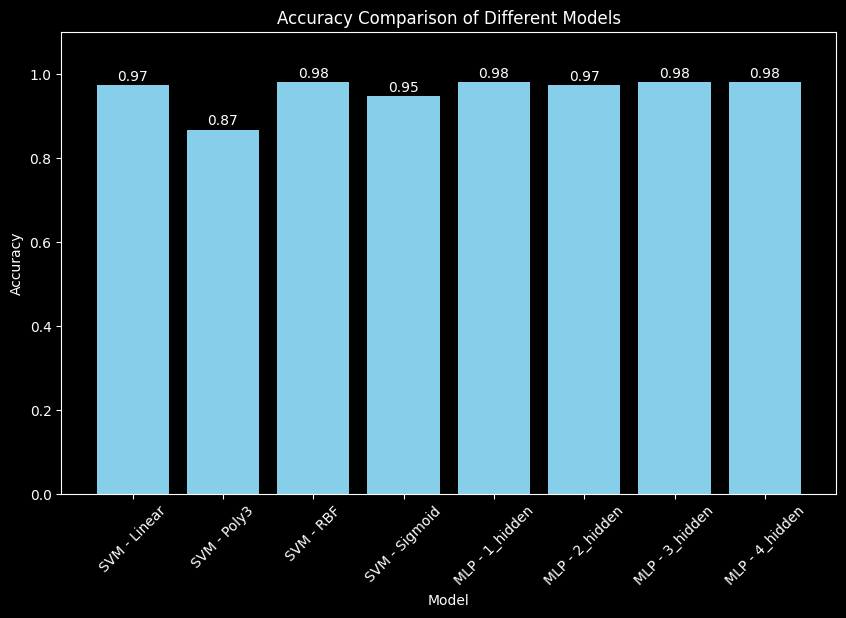

In [9]:
df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
plt.bar(df['Model'], df['Accuracy'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Different Models')
plt.ylim(0, 1.1)
for i, acc in enumerate(df['Accuracy']):
    plt.text(i, acc + 0.01, round(acc, 2), ha='center')
plt.xticks(rotation=45)
plt.show()


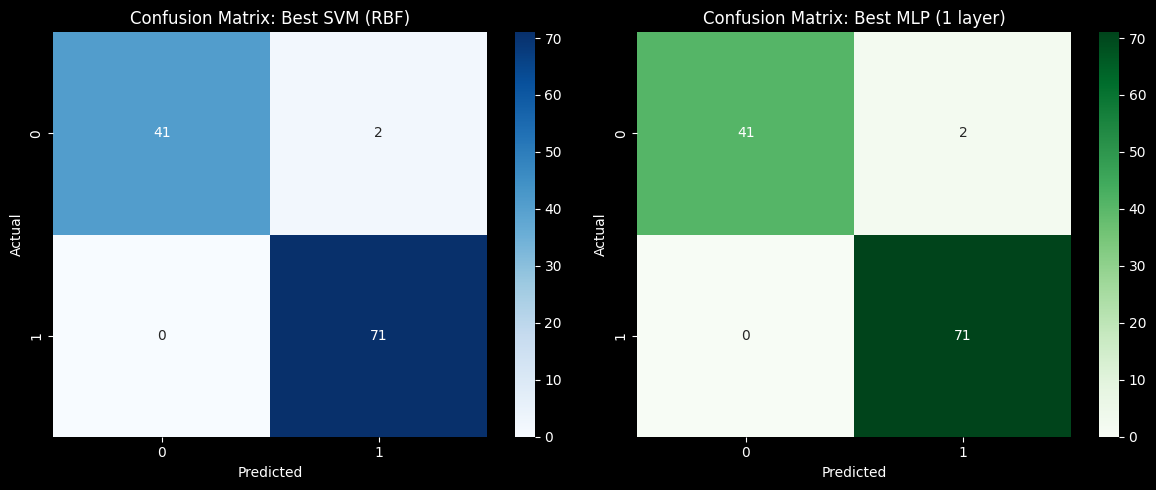

In [12]:
# Confusion Matrix for Best SVM and MLP
best_svm = rbf # SVM - RBF had 0.98 accuracy
best_mlp = clf1 # MLP - 1 layer had 0.98 accuracy

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix for Best SVM
y_pred_svm = best_svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix: Best SVM (RBF)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Confusion Matrix for Best MLP
y_pred_mlp = best_mlp.predict(X_test)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix: Best MLP (1 layer)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


### Análisis

# **1. Which SVM kernel achieved the best results and why do you think that is the case?**

El Radial Basis Function (RBF) obtuvo los mejores resultados entre los modelos SVM, alcanzando una precisión del 0.98. Probablemente esto se deba a que el conjunto de datos, aunque está estandarizado, contiene características que no presentan una relación lineal con las clases objetivo. El kernel de RBF es muy flexible y puede mapear los datos en un espacio de mayor dimensión donde un límite de decisión no lineal puede separar de forma más eficaz los casos malignos de los benignos. A diferencia del Linear kernel (precisión de 0.97) o del Polynomial kernel (precisión de 0.87), el kernel RBF maneja las no linealidades de forma natural sin el alto riesgo de sobreajuste asociado a los polinomios de alto grado ni el riesgo de subajuste de los modelos lineales.

# **2. How does increasing the number of hidden layers affect the MLP performance? Is deeper always better?**

Aumentar el número de capas ocultas de 1 a 4 no mejoró significativamente el rendimiento de la MLP en este conjunto de datos. De hecho, los modelos de 1, 3 y 4 capas alcanzaron todos una precisión del 0.98, mientras que el modelo de 2 capas bajó ligeramente hasta el 0.97. Esto indica que una mayor profundidad no siempre es sinónimo de mejor rendimiento. En el caso de un conjunto de datos relativamente pequeño y bien estructurado, como el del cáncer de mama, una sola capa oculta ya es capaz de captar las interacciones de características necesarias. Añadir más capas aumenta el riesgo de sobreajuste y dificulta el entrenamiento del modelo debido a posibles problemas de gradiente de desaparición o a una mayor complejidad sin un aumento correspondiente de la señal.

# **3. Overall, which family of models (SVM or MLP) performed better on this dataset? What factors might explain the difference?**

 Tanto la SVM (con kernel RBF) como la MLP (con 1, 3 o 4 capas) obtuvieron unos resultados excepcionales, alcanzando ambas una precisión máxima de 0.98. Sin embargo, el grupo de las SVM podría considerarse más eficiente para este conjunto de datos concreto. Las SVM son especialmente robustas cuando el número de características es relativamente alto (30 en este caso), pero el número de muestras no es muy elevado. La MLP requiere más ajuste (capas ocultas, neuronas, tasa de aprendizaje) y más recursos computacionales para lograr el mismo resultado. El hecho de que obtuvieran un rendimiento casi idéntico sugiere que el conjunto de datos está bien separado una vez escalado adecuadamente, y que ambos grupos fueron capaces de identificar el límite de decisión óptimo de manera eficaz.
